
# Lab 6: FEM 1D

### Exercise 1: Use FEM 1D to solve the EDO

Use FEM to solve the next EDO (improve the code seen in class). Compare with the analytical solution for some N elements.

\begin{equation}
-\dfrac{d^2y}{dx^2}=xe^x\,,\text{with}\; y(0)=(3-e)  \;, y(1)=0
\end{equation}


* Build a general scrip to solve a PDE of order two with Dirichlet's conditions: $y(a), y(b), x\,\epsilon\, [a,b]$. Use the method seen in class.

Nota: Solving the Green's function for this particular case we are able to find the analytical solution:
\begin{equation}
y(x) = 1-e-e^x(x-2)-x
\end{equation}

In [12]:
import numpy as np
import scipy.integrate as integrate
import matplotlib.pyplot as plt

# Referencia principal que usé para no hacer el código mostrado en clase sino uno más compacto y eficiente: 
Capítulo 6
Finite Element Methods for 1D Boundary Value Problems 
del libro Numerical Solution of Differential Equations: Introduction to Finite Difference and Finite Element Methods

En realidad no encontré el libro completo pero sí el apartado de elementos finitos: http://mitran-lab.amath.unc.edu/courses/MATH762/bibliography/LinTextBook/chap6.pdf

En FEM, cada elemento conecta solamente dos nodos consecutivos: $(x_i,x_{i+1})$

Por eso, la contribución de un elemento solo involucra los valores 
$\begin{pmatrix}
y_i\\
y_{i+1}
\end{pmatrix}$

y se representa mediante una matriz $2\times2$:

$$
K^{(e)}
=
\frac{1}{h}
\begin{pmatrix}
1&-1\\
-1&1
\end{pmatrix}.
$$

Esta matriz contiene la contribución de un solo elemento para después, las matrices de todos los elementos se suman en las posiciones correspondientes para construir la matriz global:

$$
K^{(1)}+K^{(2)}+\cdots+K^{(N)}
\longrightarrow A.
$$

En el código original esto se hace directamente:

```python
A[i-1, i-1] += 1/h
A[i-1, i]   -= 1/h
A[i, i-1]   -= 1/h
A[i, i]     += 1/h
```

pero aquí no lo haré directo sino de forma más programación, en la página 148 del libro referencia (página 16 del link pdf) se muestra el proceso que usaré correctamente

In [13]:
def fem1D(nodos: np.ndarray, funcion: callable,
          ya: float, yb: float,
          ua: float, ub: float) -> np.ndarray:
    """
    Método de elementos finitos para resolver ecuaciones diferenciales ordinarias
    de segundo orden en 1D.

    con condiciones de Dirichlet

        y(ya) = ua
        y(yb) = ub

    Parameters
    ----------
    nodos : np.ndarray
        Coordenadas de los nodos de la malla.
    funcion : callable
        Función f(x) del lado derecho de la ecuación diferencial.
    ya, yb : float
        Límites izquierdo y derecho del dominio.
    ua, ub : float
        Condiciones de frontera en ya y yb.

    Returns
    -------
    np.ndarray
        Solución aproximada en los nodos.
    """

    N = len(nodos) - 1 # número de elementos
    A = np.zeros((N + 1, N + 1)) # inicialización de matriz de rigidez
    b = np.zeros(N + 1) # inicialización de vector b para resolver A alpha=b

    # Matriz de rigidez
    for e in range(N): # por cada nodo

        x1 = nodos[e] # nodo actual (el que en las notas es x_{i-1})
        x2 = nodos[e + 1] # nodo siguiente (el que en las notas es x_{i+1})
        h = x2 - x1 # longitud del elemento

        # Matriz local del elemento
        Ke = (1 / h) * np.array([
            [1, -1],
            [-1, 1]
        ])

        # Ensamblaje de la matriz global
        A[e:e+2, e:e+2] += Ke # se hace e:e+2 porque se suman los dos nodos del elemento

    # Funciones de forma lineales
    def phi1(x, x1, x2): # funcion phi1 como el tramo con x entre [x_{i-1}, x_{i}]
        return (x2 - x) / (x2 - x1) 

    def phi2(x, x1, x2): # funcion phi2 como el tramo con x entre [x_{i}, x_{i+1}]
        return (x - x1) / (x2 - x1)

    for e in range(N):

        x1 = nodos[e]
        x2 = nodos[e + 1]

        # Integrales locales
        b1 = integrate.quad(
            lambda x: funcion(x) * phi1(x, x1, x2),
            x1, x2
        )[0]

        b2 = integrate.quad(
            lambda x: funcion(x) * phi2(x, x1, x2),
            x1, x2
        )[0]

        # Ensamblaje
        b[e] += b1
        b[e + 1] += b2
    
    # Condiciones de Dirichlet
    # Las condiciones conocidas se pasan al lado derecho
    b -= A[:, 0] * ua
    b -= A[:, N] * ub

    # Primera condición: y(ya) = ua
    A[0, :] = 0
    A[:, 0] = 0
    A[0, 0] = 1
    b[0] = ua

    # Segunda condición: y(yb) = ub
    A[N, :] = 0
    A[:, N] = 0
    A[N, N] = 1
    b[N] = ub

    # Solución sistema A * alpha = b
    solucion = np.linalg.solve(A, b)
    return solucion

In [14]:
def graficar_fem(nodos: np.ndarray, solucion: np.ndarray, exacta: callable, N: int) -> None:
    """
    Grafica la solución FEM, la solución analítica y la interpolación.

    Parameters
    ----------
    nodos : np.ndarray
        Coordenadas de los nodos de la malla.
    solucion : np.ndarray
        Solución aproximada en los nodos.
    exacta : callable
        Función que representa la solución exacta.
    N : int
        Número de elementos en la malla.
    
    Returns
    -------
    None (grafica)
    """

    x_plot = np.linspace(nodos[0], nodos[-1], 500)
    y_exacta = exacta(x_plot)
    y_interp = np.interp(x_plot, nodos, solucion)

    plt.figure(figsize=(7, 4))
    plt.plot(x_plot, y_exacta, label='Solución exacta', color='black')
    plt.plot(nodos, solucion, 'o', label='Nodos FEM', color='red')
    plt.plot(x_plot, y_interp, '--', label='Interpolación FEM', color='blue')
    
    plt.xlabel(r'$x$')
    plt.ylabel(r'$y(x)$')
    plt.title(f'FEM 1D: {N} elementos, {N+1} nodos')
    plt.legend()
    plt.grid(True)
    plt.show()

Nodos:
[0.  0.2 0.4 0.6 0.8 1. ]

Solución FEM:
[0.28171817 0.28024314 0.26863769 0.23268449 0.15236729 0.        ]


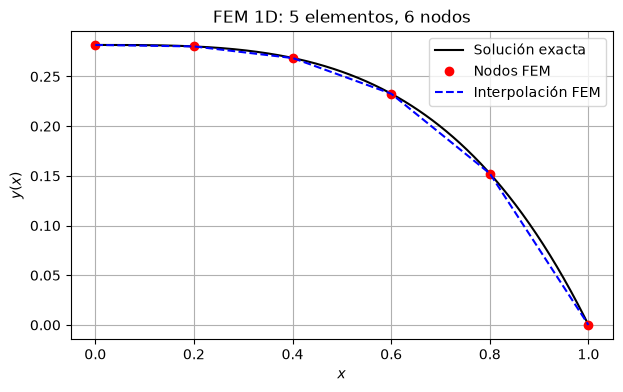

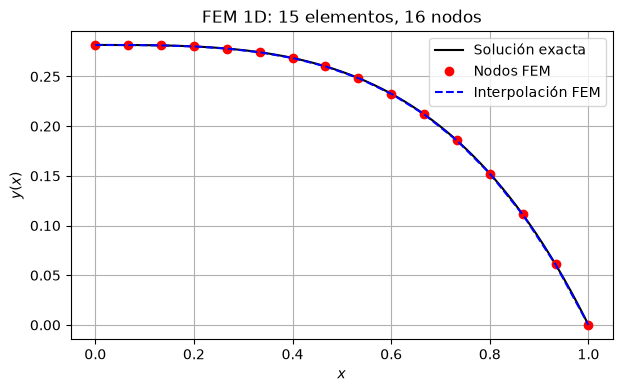

In [18]:
funcion = lambda x: x * np.exp(x)
solucion_exacta = lambda x: 1 - np.e - np.exp(x) * (x-2) - x

N = 5
nodos = np.linspace(0, 1, N + 1)
solucion5 = fem1D(nodos, funcion, 0, 1, 3 - np.e, 0)
solucion15 = fem1D(np.linspace(0, 1, 15 + 1), funcion, 0, 1, 3 - np.e, 0)
print("Nodos:")
print(nodos)

print("\nSolución FEM:")
print(solucion5)

graficar_fem(nodos, solucion5, solucion_exacta, N)
graficar_fem(np.linspace(0, 1, 15 + 1), solucion15, solucion_exacta, 15)